# Compute the number of generations since admixture from admixture tract lengths

In [1]:
import numpy as np
import patsy as ps
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina', 'png')
import seaborn as sns
sns.set()
sns.set_style('ticks')

### Generate some dummy exponentially distributed length data

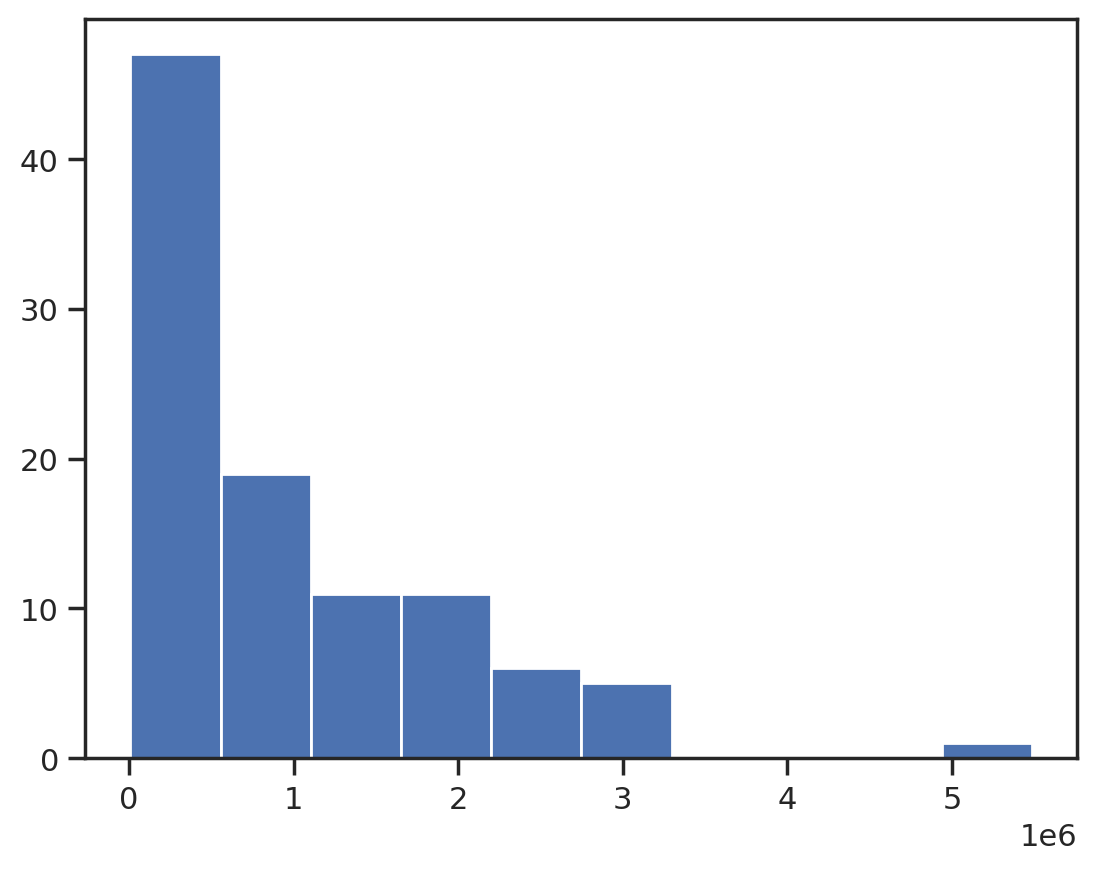

In [2]:
# dummy length data
from numpy.random import exponential
phys_lengths = exponential(scale=1000000, size=100) #+ 1000000000
plt.hist(phys_lengths) ;

In [3]:
mean_rec_rate = 1e-8
lengths = phys_lengths * mean_rec_rate

### Compute the empirical CDF

In [4]:
def ecdf(data):
    """ Compute ECDF """
    x = np.sort(data)
    n = x.size
    y = np.arange(1, n+1) / n
    return x, y

val, prob = ecdf(lengths)

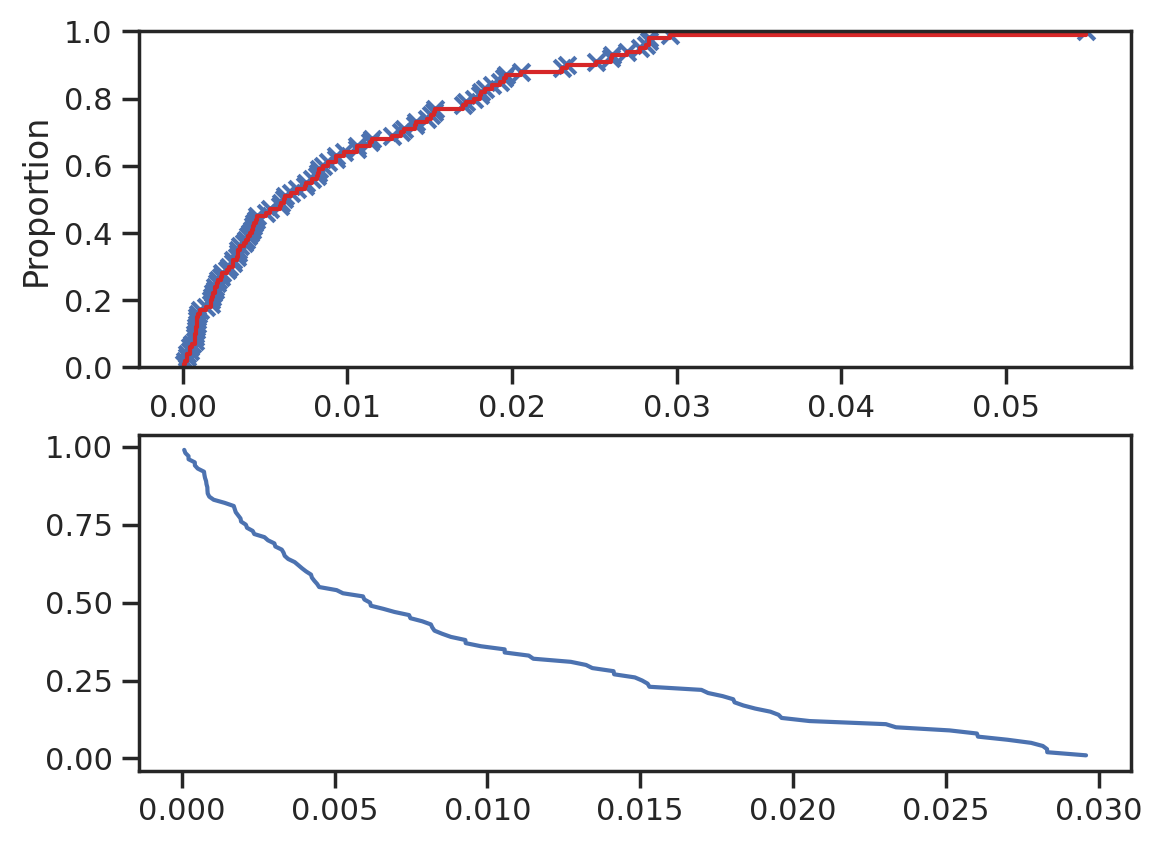

In [5]:
plt.subplot(211)
plt.scatter(val, prob, marker='x')
# sanity check
sns.ecdfplot(x=val, color='tab:red') 

# PDF
plt.subplot(212)
d, p = val[:-1], 1-prob[:-1] # leave out last one to avoid division by zero
plt.plot(d, p) ;

### Estimate the number of generations

The admixture is likely not the result of a single admixture event, but if we assume that it is, the length distribution of tracts is well approximated by $y=Ae^{−(n−1)d}$. Here $n$ is the number of generations since the admixture event and $d$ is genetic distance (physical length times mean recombination rate per base) and $A$ is a scaling factor. We fit a line to the log of the complementary cummulative distribution (the PDF) of tract lengths and, since $\ln(y)=−(n−1)d+\ln(A)$, the slope of the fitted line is n−1.

Intercept     -0.006326
d           -106.331405
dtype: float64

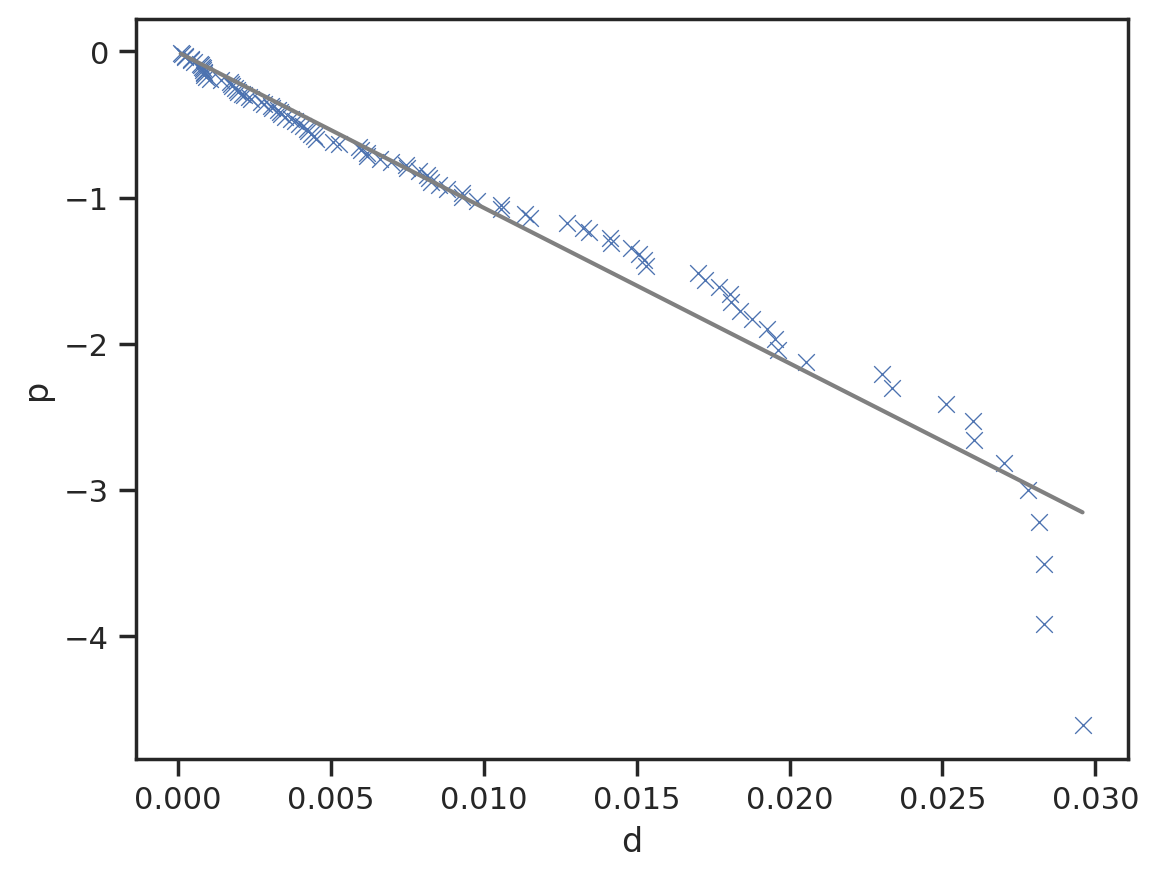

In [6]:
# mask = ~np.isnan(x)
# df = pd.DataFrame(dict(d=d[mask], p=np.log(1-p[mask])))

df = pd.DataFrame(dict(d=d, p=np.log(p)))

y, X = ps.dmatrices('p ~ d',data = df, return_type = 'dataframe')
model = sm.OLS(y,X)
results = model.fit()
predicted_p = results.predict()
p_residuals = df.p - predicted_p

ax = sns.scatterplot(x=df.d, y=df.p, marker='x');
ax.plot(df.d, predicted_p, color='grey', marker=None);
results.params

Generations since admixture pulse is:

In [7]:
round(-results.params.d + 1)

107

Loading in data for Tanzania and Ethiopia

In [9]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': 0,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': 0}

df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)
df_l = []
for c in ["chr{}".format(x) for x in (range(1, 21))] + ["chrX"]:
    genetic_map = "/home/eriks/baboondiversity/data/PG_panu3_recombination_map/mikumi_pyrho_genetic_map_{}.txt"
    chr_recomb = pd.read_csv(genetic_map.format(c), sep=" ")
    df_l.append(chr_recomb)
recomb_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [10]:
df_l = []
for c in length_df.chrom.unique():
    print(c)
    
    l_df = length_df.loc[length_df.chrom == c].copy()
    if c == "female_chrX" or c == "all_chrX":
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    df_l.append(l_df)
df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [12]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Cynocephalus, Central Tanzania': 0,
 'Papio, Senegal': 0,
 'Anubis, Tanzania': 0}

df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [13]:
df_l = []
for c in length_df.chrom.unique():
    print(c)
    
    l_df = length_df.loc[length_df.chrom == c].copy()
    if c == "female_chrX" or c == "all_chrX":
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    df_l.append(l_df)
df_eth = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [14]:
meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

df["Species"] = df.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Species)))
df["Origin"] = df.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin)))

df_eth["Species"] = df_eth.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Species)))
df_eth["Origin"] = df_eth.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin+"_eth_case")))
length_df_tanz_eth = pd.concat([df, df_eth])

In [15]:
length_df_tanz_eth

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,start_cM,end,end_cM,Species,Origin
0,160,9915383,9915224,"Kindae, Zambia",0,Sci_16066,0,chr1,0.000057,9915384,13.556968,cynocephalus,"Mikumi, Tanzania"
1,9915384,10291147,375764,"Hamadryas, Ethiopia",1,Sci_16066,0,chr1,13.556968,10291148,13.916870,cynocephalus,"Mikumi, Tanzania"
2,10291148,33224041,22932894,"Kindae, Zambia",0,Sci_16066,0,chr1,13.916870,33224042,43.207802,cynocephalus,"Mikumi, Tanzania"
3,33224042,33578534,354493,"Hamadryas, Ethiopia",1,Sci_16066,0,chr1,43.207802,33578535,43.351891,cynocephalus,"Mikumi, Tanzania"
4,33578535,39239117,5660583,"Kindae, Zambia",0,Sci_16066,0,chr1,43.351891,39239118,47.063374,cynocephalus,"Mikumi, Tanzania"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,91954355,92441774,487420,"Cynocephalus, Central Tanzania",0,PD_0792,1,female_chrX,82.557416,92441775,82.984241,kindae,"Chunga, Zambia_eth_case"
29,92441775,92824755,382981,"Hamadryas, Ethiopia",1,PD_0792,1,female_chrX,82.984241,92824756,83.935652,kindae,"Chunga, Zambia_eth_case"
30,92824756,94470854,1646099,"Cynocephalus, Central Tanzania",0,PD_0792,1,female_chrX,83.935652,94470855,84.850342,kindae,"Chunga, Zambia_eth_case"
31,94470855,95908432,1437578,"Hamadryas, Ethiopia",1,PD_0792,1,female_chrX,84.850342,95908433,85.704730,kindae,"Chunga, Zambia_eth_case"


In [16]:
#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia_eth_case',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
length_df_tanz_eth = length_df_tanz_eth.loc[length_df_tanz_eth.Origin.isin(origins_interest)]
length_df_tanz_eth["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(length_df_tanz_eth["n/s"],
                                                                         length_df_tanz_eth["Species"],
                                                                        length_df_tanz_eth["Origin"])]
length_df_tanz_eth["cM_length"] = length_df_tanz_eth.end_cM-length_df_tanz_eth.start_cM

/tmp/47761274/ipykernel_3950609/2485582720.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  length_df_tanz_eth["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
/tmp/47761274/ipykernel_3950609/2485582720.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  length_df_tanz_eth["cM_length"] = length_df_tanz_eth.end_cM-length_df_tanz_eth.start_cM


In [17]:
length_df_tanz_eth.loc[length_df_tanz_eth.minor_parent_percentage == 1]

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,start_cM,end,end_cM,Species,Origin,minor_parent_percentage,cM_length
1,9915384,10291147,375764,"Hamadryas, Ethiopia",1,Sci_16066,0,chr1,13.556968,10291148,13.916870,cynocephalus,"Mikumi, Tanzania",1,0.359901
3,33224042,33578534,354493,"Hamadryas, Ethiopia",1,Sci_16066,0,chr1,43.207802,33578535,43.351891,cynocephalus,"Mikumi, Tanzania",1,0.144089
47,214850280,214970250,119971,"Hamadryas, Ethiopia",1,Sci_16066,0,chr1,168.300748,214970251,168.446887,cynocephalus,"Mikumi, Tanzania",1,0.146139
1,7037733,7672850,635118,"Hamadryas, Ethiopia",1,Sci_16066,1,chr1,10.377503,7672851,10.888662,cynocephalus,"Mikumi, Tanzania",1,0.511159
3,9915384,10291147,375764,"Hamadryas, Ethiopia",1,Sci_16066,1,chr1,13.556968,10291148,13.916870,cynocephalus,"Mikumi, Tanzania",1,0.359901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,134272891,134703012,430122,"Hamadryas, Ethiopia",1,PD_0744,1,female_chrX,121.647302,134703013,122.002305,anubis,"Gog Woreda, Gambella region, Ethiopia_eth_case",1,0.355003
130,134821453,135373119,551667,"Hamadryas, Ethiopia",1,PD_0744,1,female_chrX,122.097994,135373120,122.658891,anubis,"Gog Woreda, Gambella region, Ethiopia_eth_case",1,0.560897
132,135612557,137015917,1403361,"Hamadryas, Ethiopia",1,PD_0744,1,female_chrX,122.873780,137015918,123.208238,anubis,"Gog Woreda, Gambella region, Ethiopia_eth_case",1,0.334458
134,137227765,138106760,878996,"Hamadryas, Ethiopia",1,PD_0744,1,female_chrX,123.231057,138106761,123.785145,anubis,"Gog Woreda, Gambella region, Ethiopia_eth_case",1,0.554088


In [26]:
length_df_tanz_eth["chrom_type"] = ["autosome" if x not in ['all_chrX', 'female_chrX'] else "chrX" for x in length_df_tanz_eth.chrom]

/tmp/47761274/ipykernel_3950609/4277343167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  length_df_tanz_eth["chrom_type"] = ["autosome" if x not in ['all_chrX', 'female_chrX'] else "chrX" for x in length_df_tanz_eth.chrom]


In [28]:
length_sum = length_df_tanz_eth.loc[length_df_tanz_eth.minor_parent_percentage == 1].groupby(["individual", "chrom_type"])["length"].sum().reset_index()
length_median = length_df_tanz_eth.loc[length_df_tanz_eth.minor_parent_percentage == 1].groupby(["individual", "chrom_type"])["length"].median().reset_index()
length_df = length_df_tanz_eth.groupby(["individual", "chrom_type"])["length"].sum().reset_index()
length_df = length_df.merge(length_sum, on=["individual","chrom_type"])
length_df = length_df.merge(length_median, on=["individual","chrom_type"])

In [29]:
length_df["Admix Proportion"] = length_df.length_y/length_df.length_x
length_df["Median Fragment"] = length_df.length

In [104]:
def ecdf(data):
    """ Compute ECDF """
    x = np.sort(data)
    n = x.size
    y = np.arange(1, n+1) / n
    return x, y

origin_l, date_l, morgan_l, mean_l, median_l, sum_l, total_size = [], [], [], [], [], [], []

for o in length_df_tanz_eth.Origin.unique():
    print(o)
    s_df = length_df_tanz_eth.loc[length_df_tanz_eth.Origin == o]
    for ID in s_df.individual.unique():
        print(ID)
        ss_df = s_df.loc[(s_df.individual == ID) & (s_df["minor_parent_percentage"] == 1) &
                         ~(s_df.chrom).isin(["all_chrX", "female_chrX"])]
        total_size.append(s_df.loc[(s_df.individual == ID) &
                         ~(s_df.chrom).isin(["all_chrX", "female_chrX"])].cM_length.sum())
        lengths = ss_df.cM_length/100
        val, prob = ecdf(lengths.sort_values(ascending=False).iloc[:len(lengths)//5])
        d, p = val[:-1], 1-prob[:-1]
        m_df = pd.DataFrame(dict(d=d, p=np.log(p)))

        y, X = ps.dmatrices('p ~ d',data = m_df, return_type = 'dataframe')
        model = sm.GLM(y,X, var_weights=X.d)
        results = model.fit()
        predicted_p = results.predict()
        p_residuals = m_df.p - predicted_p
        print(round(-results.params.d + 1), lengths.mean(), lengths.median(), lengths.sum())
        origin_l.append(o), date_l.append(-results.params.d + 1), morgan_l.append(lengths.sum())
        mean_l.append(lengths.mean()*100), median_l.append(lengths.median()*100), sum_l.append(lengths.sum()*100)

Mikumi, Tanzania
Sci_16066
258 0.002693191374966133 0.0020203523452259732 0.6544455041167703
Sci_16098
291 0.0026363058762375797 0.0018392750380437305 0.5562605398861293
PD_0268
219 0.0030410683746900785 0.0020781803249514752 0.7602670936725197
PD_0269
414 0.002460340988885798 0.0018385594285501839 0.5634180864548477
PD_0270
578 0.0026001400260110665 0.0019146012968806448 0.5928319259305231
PD_0271
231 0.002950974239878657 0.0020793335600479425 0.6580672554929405
PD_0272
182 0.002841401189625196 0.002087764949405937 0.5086108129429101
PD_0637
219 0.0025058995529404966 0.0018581360000138147 0.5688391985174928
PD_0687
164 0.0028514780690840525 0.001762386458999483 0.6159192629221554
PD_0688
326 0.002840307085452145 0.0020913605205665677 0.6135063304576633
PD_0689
159 0.00320268519015323 0.002151729124308801 0.7878605567776945
PD_0690
168 0.0028327600406588783 0.0017801296147235846 0.5778830482944112
PD_0691
246 0.0027983625070768688 0.001989565882847586 0.7191791643187553
PD_0745
142 0.0

217 0.0034248284930806306 0.0024885698315388195 2.5549220558381505
PD_0676
211 0.003385349553318249 0.0025567628916014227 2.295266997149773
PD_0677
198 0.003497568873164034 0.002535463490018053 2.476278762200136
PD_0678
280 0.003415593182991368 0.002502675060288553 2.319187771251139
PD_0679
227 0.0034074442413907047 0.002449058487490774 2.4022481901804467
PD_0680
282 0.0033798254909662103 0.0025467624374915588 2.3354594142576515
PD_0681
216 0.0033089031893018548 0.0024241121676308805 2.2434363623466576
PD_0682
191 0.0034614899515728616 0.0025803120150850846 2.2707374082317973
PD_0683
229 0.0032421184011043568 0.0023729809228241992 2.2694828807730496
PD_0684
222 0.0034785620711851005 0.00241949894668096 2.8767708328700783
PD_0685
178 0.00333578900876142 0.002376910623233002 2.8220775014121613
PD_0686
149 0.0036494808114533083 0.0024109560434861345 3.0947597281124053
Tarangire, Tanzania
PD_0243
153 0.0060000777796630446 0.003976093125607107 9.930128725342339
PD_0244
91 0.0061052059060299

In [107]:
date_df = pd.DataFrame({"Origin": origin_l, "Inferred date bases on fragment ecdf": date_l,
                        "Total admixture in Morgans": morgan_l,
                        "Total admixture in cM": sum_l,
                       "Mean admixture fragment length in cM": mean_l,
                       "Median admixture fragment length in cM": median_l,
                       "Total fragment size": total_size})
date_df["Proportion admixed in cM"] = date_df["Total admixture in cM"]/date_df["Total fragment size"]
#date_df["log_date"] = np.log(date_df["Inferred mean data base on fragment ecdf"])

[Text(0.5, 1.0, 'Admixture on the autosomes for Tanzanian olive populations')]

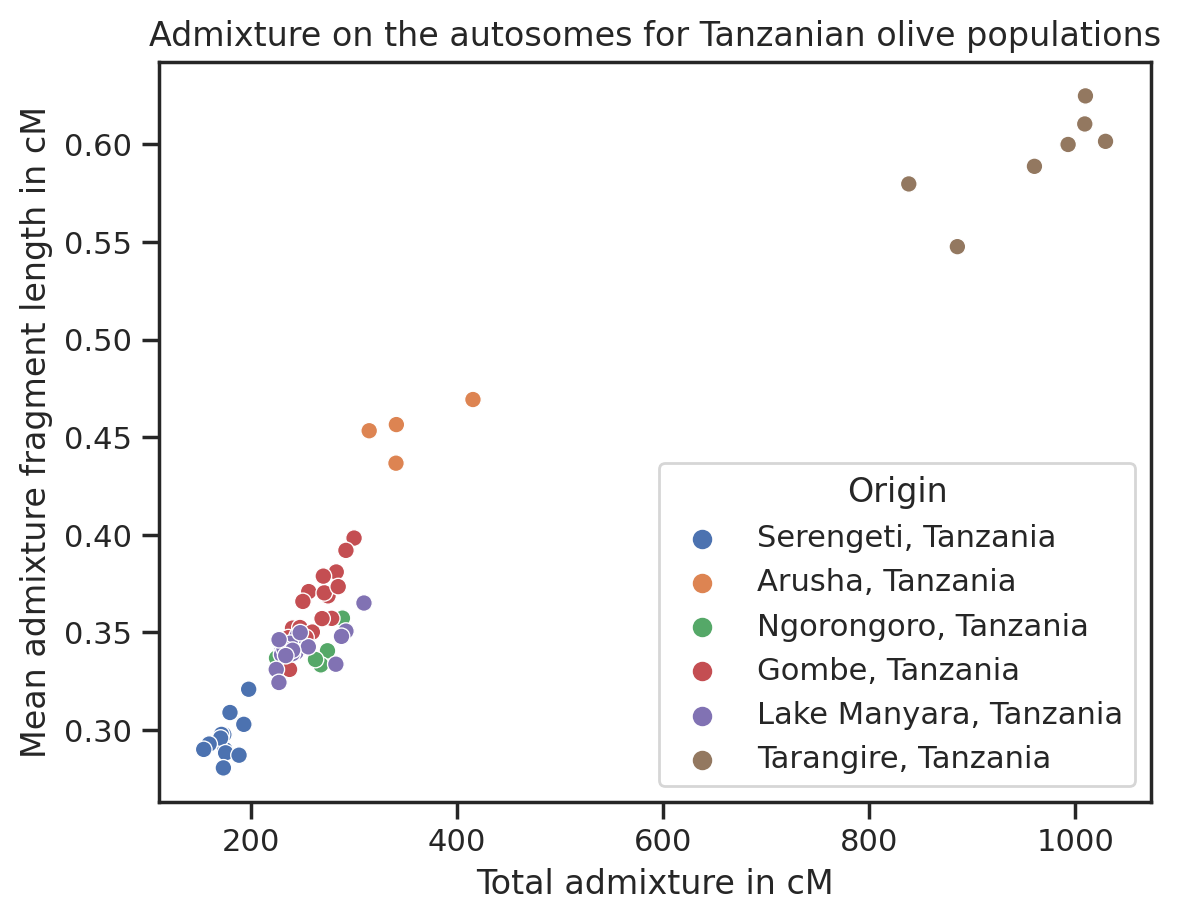

In [108]:
g = sns.scatterplot(data=date_df.loc[date_df.Origin.isin(["Serengeti, Tanzania",
                                                 "Tarangire, Tanzania",
                                                "Lake Manyara, Tanzania",
                                                "Ngorongoro, Tanzania",
                                                "Gombe, Tanzania",
                                                "Arusha, Tanzania"])], 
           x="Total admixture in cM", y="Mean admixture fragment length in cM", hue="Origin")
g.set(title="Admixture on the autosomes for Tanzanian olive populations")

[Text(0.5, 1.0, 'Admixture on the autosomes for Tanzanian olive populations')]

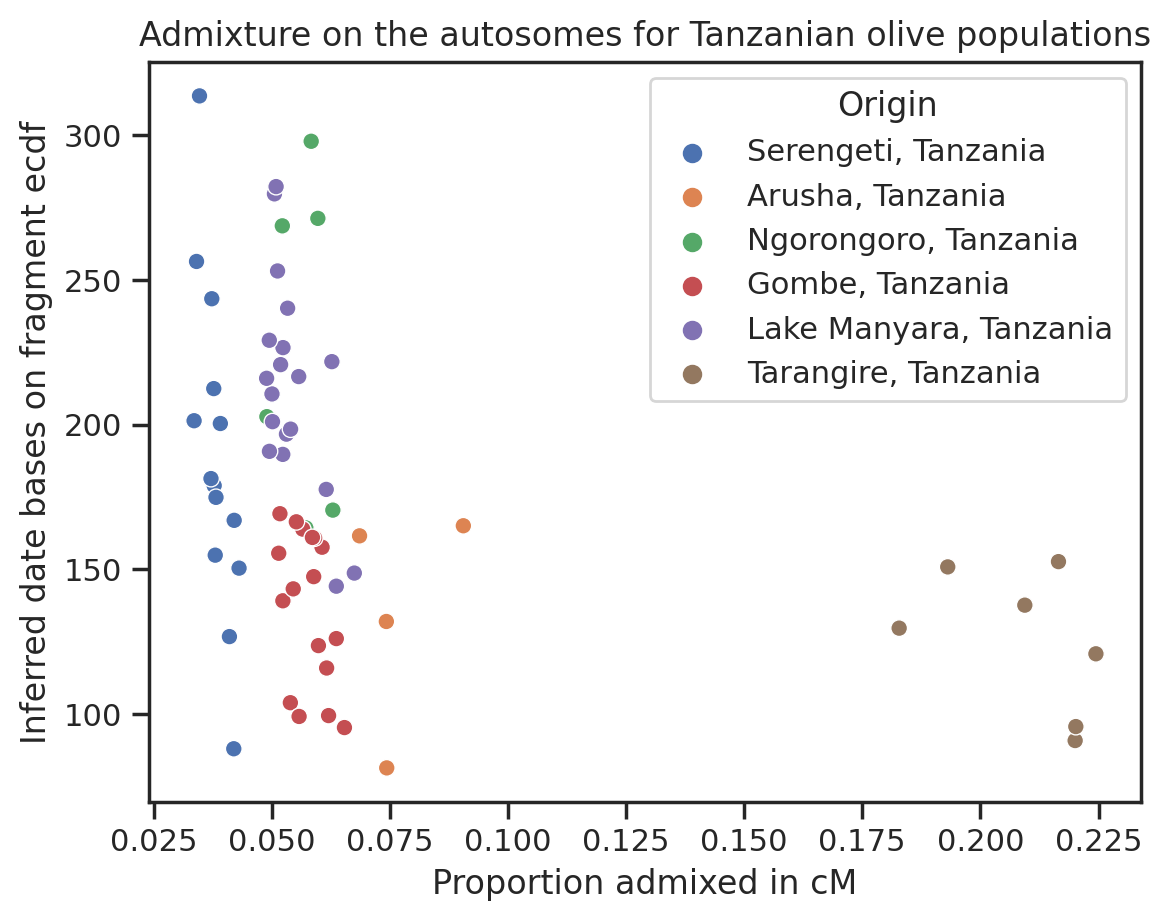

In [109]:
g = sns.scatterplot(data=date_df.loc[date_df.Origin.isin(["Serengeti, Tanzania",
                                                 "Tarangire, Tanzania",
                                                "Lake Manyara, Tanzania",
                                                "Ngorongoro, Tanzania",
                                                "Gombe, Tanzania",
                                                "Arusha, Tanzania"])], 
           x="Proportion admixed in cM", y="Inferred date bases on fragment ecdf", hue="Origin")
g.set(title="Admixture on the autosomes for Tanzanian olive populations")

[Text(0.5, 1.0, 'Admixture on the autosomes for Tanzanian yellow populations')]

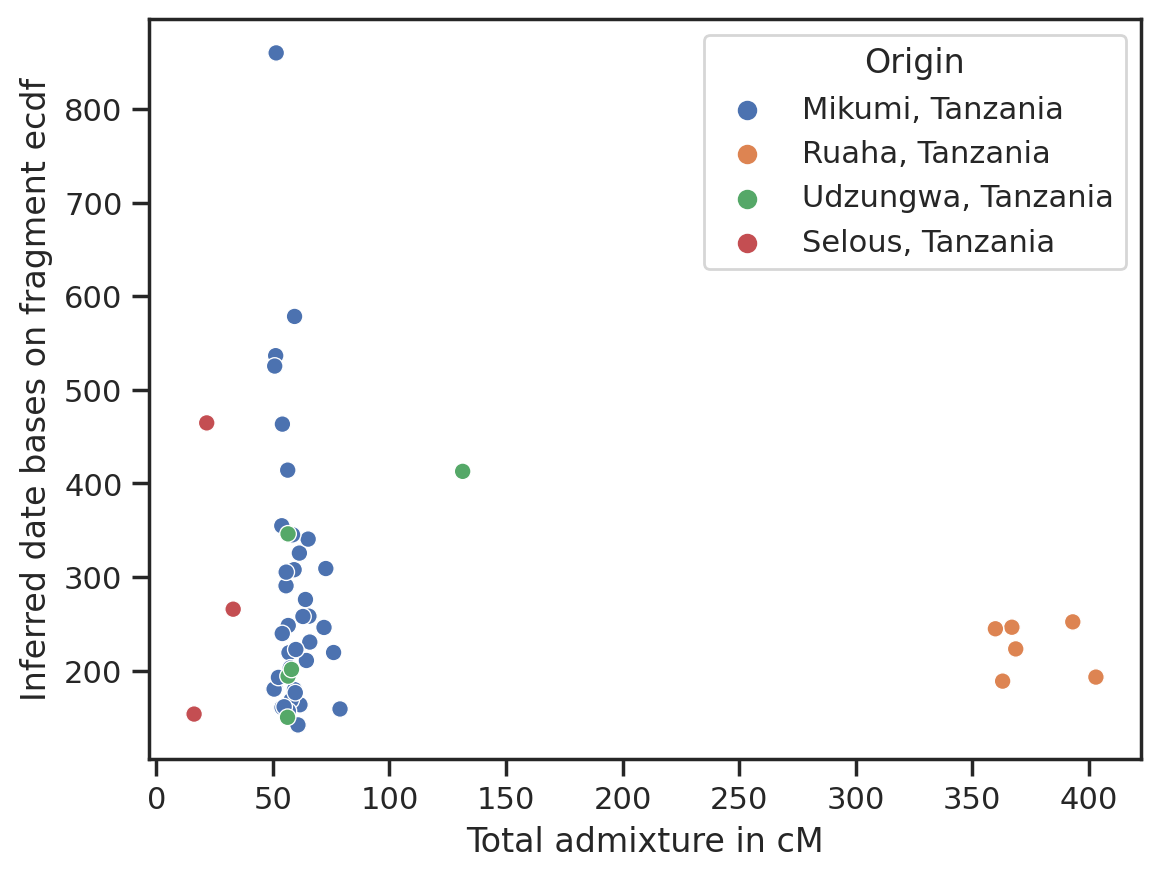

In [103]:
sns.scatterplot(data=date_df.loc[date_df.Origin.isin(["Selous, Tanzania",
                                                 "Udzungwa, Tanzania",
                                                "Ruaha, Tanzania",
                                                "Mikumi, Tanzania"])], 
           x="Total admixture in cM", y="Inferred date bases on fragment ecdf", hue="Origin")
g.set(title="Admixture on the autosomes for Tanzanian yellow populations")

In [94]:
date_df_renamed = date_df.copy() 
date_df_renamed["Origin"] = ["Gog, Ethiopian admixture case" if x == "Gog Woreda, Gambella region, Ethiopia_eth_case" else x for x in date_df["Origin"]]

<Axes: xlabel='Total admixture in cM', ylabel='Inferred date bases on fragment ecdf'>

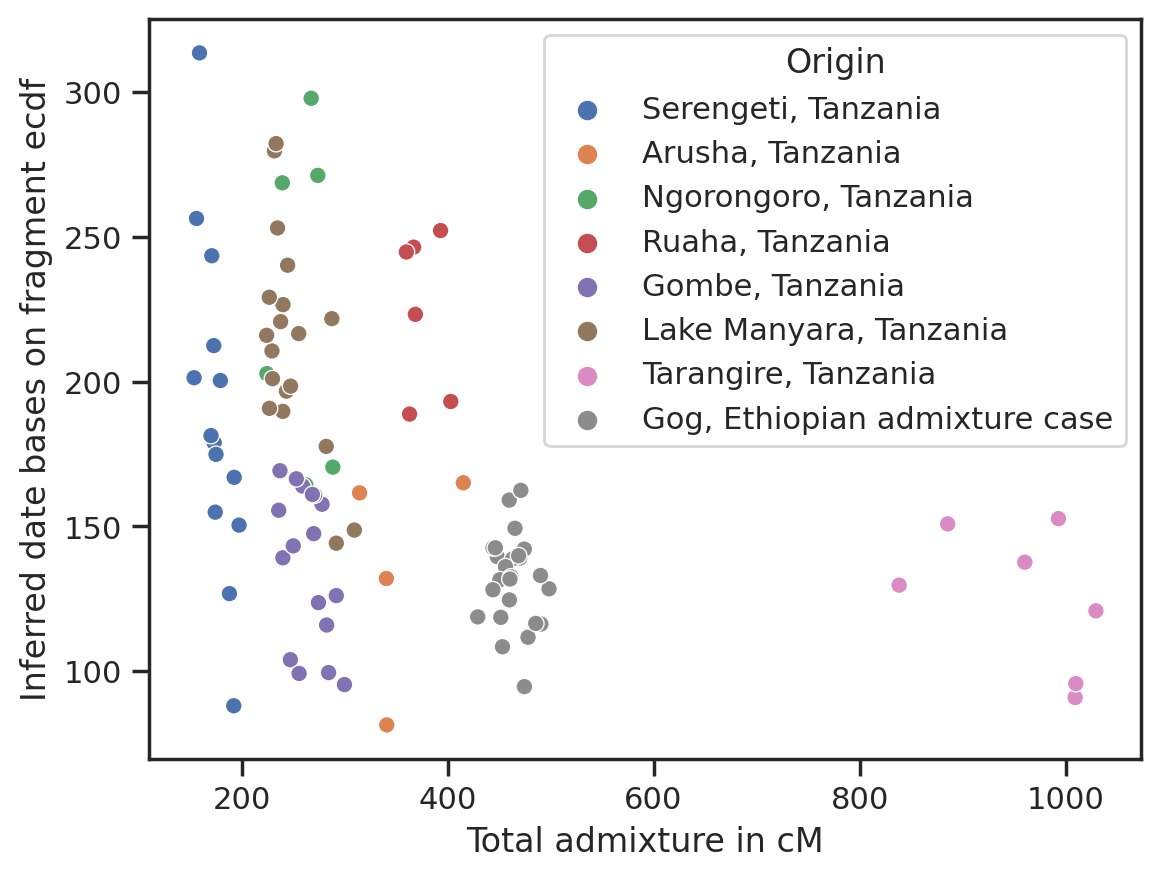

In [98]:
sns.scatterplot(data=date_df_renamed.loc[date_df_renamed.Origin.isin(["Serengeti, Tanzania",
                                                 "Tarangire, Tanzania", 'Arusha, Tanzania',
                                                "Lake Manyara, Tanzania",
                                                "Ngorongoro, Tanzania",
                                                "Gombe, Tanzania",
                                                "Ruaha, Tanzania","Gog, Ethiopian admixture case"])], 
           x="Total admixture in cM", y="Inferred date bases on fragment ecdf", hue="Origin")

Intercept      0.554655
d           -130.542495
dtype: float64

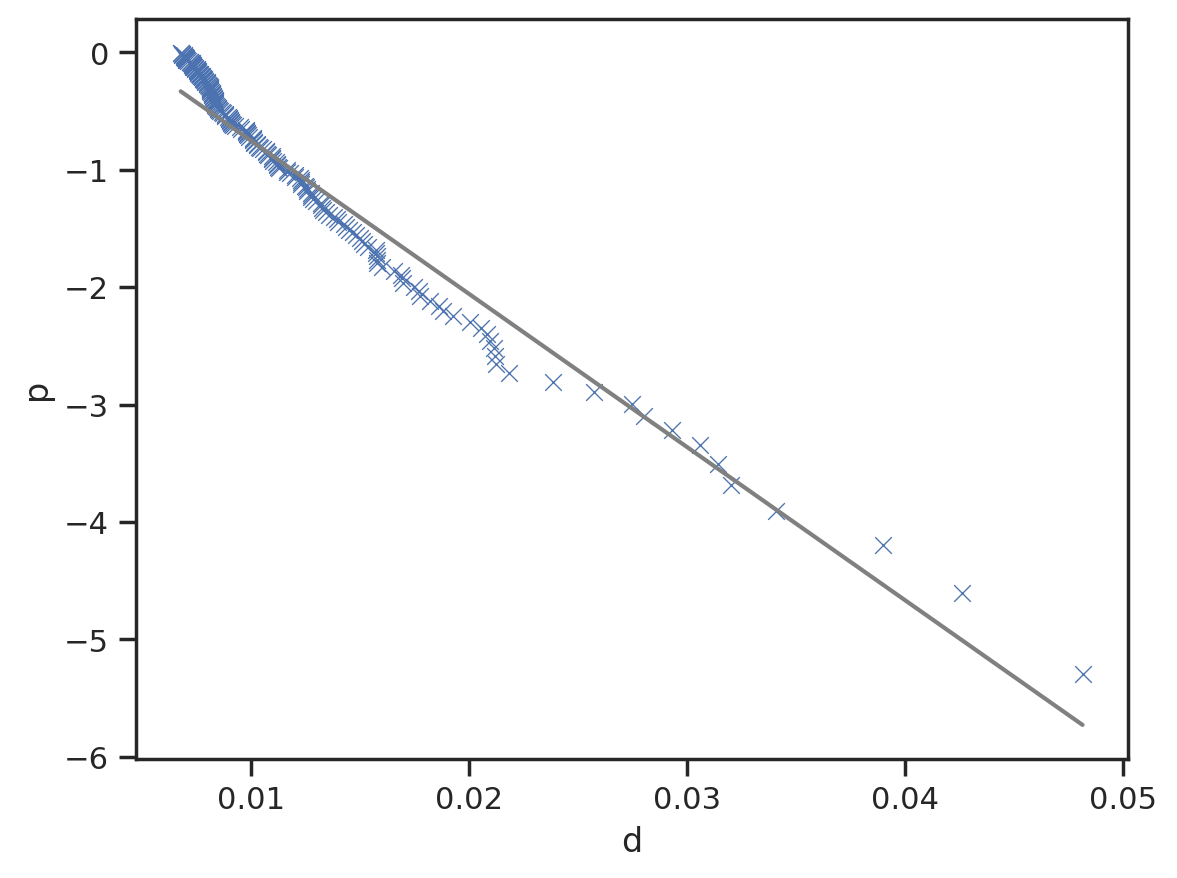

In [23]:
ax = sns.scatterplot(x=m_df.d, y=m_df.p, marker='x');
ax.plot(m_df.d, predicted_p, color='grey', marker=None);
results.params

<Axes: xlabel='cM_length', ylabel='Count'>

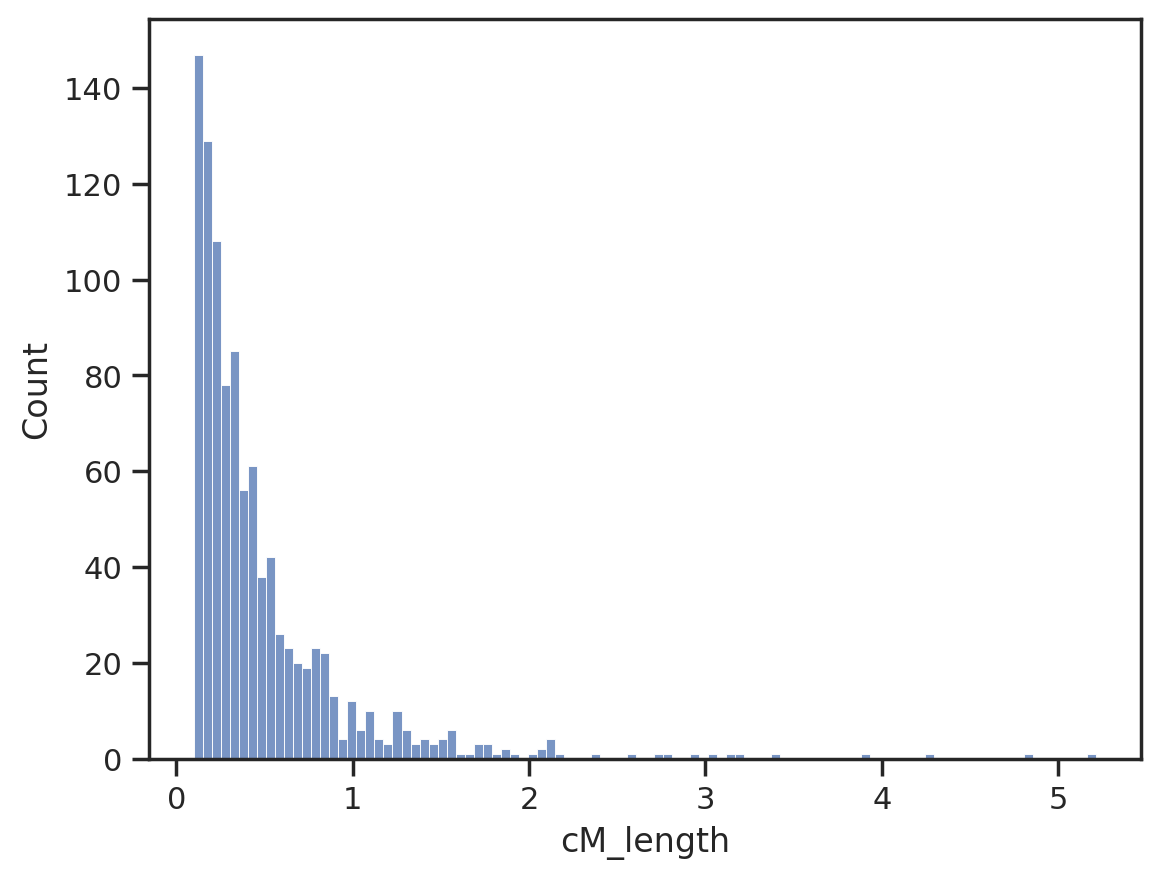

In [24]:
sns.histplot(ss_df.cM_length, bins=100)